# Testing Catsniffer firmware

Before you can use CatSniffer for sniffing, fuzzing, or replaying traffic, you’ll need to **install the required tools**, **set up dependencies**, **identify your serial port**, and finally **flash the firmware** onto the board. This section guides you through that process in a reproducible way inside Jupyter.


### 1. Installing tools and dependencies
CatSniffer developed catnip_uploader which internally uses Texas Instruments’ bootloader utility (`cc2538-bsl.py`) to communicate with the device and attempts to simplify the process of uploading firmware.

Download or update the Catsniffer tools repository to make sure you have the latest working version.

In [ ]:
import os
import subprocess

repo_url = "https://github.com/ElectronicCats/CatSniffer-Tools.git"
target_dir = "CatSniffer-Tools"

if not os.path.exists(target_dir):
    print(f"Cloning repository {repo_url}...")
    !git clone {repo_url}
else:
    print(f"Updating existing repository in {target_dir}...")
    try:
        subprocess.run(["git", "-C", target_dir, "pull"], check=True)
        print("Repository updated successfully.")
    except subprocess.CalledProcessError as e:
        print(f"Failed to update repository: {e}")

#### Dependencies
You’ll need a Python 3 environment with standard libraries plus `pyserial`, `intelhex` and others.  
The notebook will verify these dependencies and help you install them if they’re missing.

In [ ]:
# Install dependencies
import sys
!{sys.executable} -m pip install "typer[all]" pyserial intelhex requests ipywidgets

### 2. Identifying the serial port
The CatSniffer appears as a serial device when connected over USB. The exact name depends on your operating system:
- **macOS**: `/dev/cu.usbmodemXXXX`  
- **Linux**: `/dev/ttyACM0`, `/dev/ttyUSB0`, etc.  
- **Windows**: `COM3`, `COM4`, etc.  

In this section, you’ll confirm which port your CatSniffer is attached to so flashing can proceed without errors.

Connect your Catsniffer via USB to the workstation and identify the serial port to which it is assigned.

In [ ]:
import serial.tools.list_ports
import ipywidgets as widgets
from IPython.display import display, clear_output

available_ports = []
scan_ports = widgets.Button(description="Scan ports")

ports_dropdown = widgets.Dropdown(
    options=available_ports,
    description='Ports:',
    layout=widgets.Layout(width='20%')
)

def detect_serial_ports(btn):
    # limpiamos la lista
    available_ports.clear()

    ports = serial.tools.list_ports.comports()
    for port in ports:
        if any(x in port.device for x in ["ttyUSB", "ttyACM", "cu.usbmodem", "usbserial", "COM"]):
            available_ports.append(port.device)

    # actualizar el dropdown
    ports_dropdown.options = available_ports

detect_serial_ports(None)

scan_ports.on_click(detect_serial_ports)

display(scan_ports, ports_dropdown)
    

### 3. Uploading firmware
With the right tools installed and the serial port identified, you can upload a firmware image (for example, the sniffer firmware) using the notebook’s helper buttons. The process runs `catnip_uploader.py` to flash/load your firmware file (.hex format).  

On success, you’ll see confirmation messages, and the device will be ready for use.


In [ ]:
# --- What this cell does ----------------------------------------------------
# Flashes CatSniffer using the local catnip_uploader/catnip_uploader.py script.
# It runs the Catnip utility with EXACTLY these arguments: load <firmware> --validate
#
# Expected output:
# - On success you'll see the tool's success messages such as 'Firmware uploaded successfully'.
# - On error you'll see stdout/stderr with details (bad port, missing file, etc.).
# ---------------------------------------------------------------------------
import os, sys, subprocess
from IPython.display import display, clear_output
import ipywidgets as widgets

# Defaults (adjust as needed)
default_port = "/dev/select.your.serial.port"
default_hex = "sniffer_fw_CC1352P_7_v1.10.hex"  # <- your .hex file here
selected_port = ports_dropdown.value

# UI widgets
port_input = widgets.Text(value=selected_port, description="Port:")
hex_input = widgets.Text(value=default_hex, description="File (.hex):")
flash_btn = widgets.Button(description="⚡ Flash Firmware", button_style="danger")
output = widgets.Output()

def _resolve_cc2538_py():
    """ Return absolute path to catnip_uploader/catnip_uploader.py (relative to this notebook). """
    candidates = [
        "CatSniffer-Tools/catnip_uploader/catnip_uploader.py",
        "./CatSniffer-Tools/catnip_uploader/catnip_uploader.py",
    ]
    for c in candidates:
        p = os.path.abspath(c)
        if os.path.isfile(p):
            return p
    return None

def flash_firmware(_):
    with output:
        clear_output(wait=True)
        cc2538 = _resolve_cc2538_py()
        port = port_input.value.strip()
        hexfile = hex_input.value.strip()

        if not cc2538:
            print("Could not find catnip_uploader/catnip_uploader.py (relative to this notebook).")
            return
        if not os.path.isfile(hexfile):
            print(f"HEX file not found: {hexfile}")
            return
        if not port:
            print("You must specify a serial port.")
            return

        cmd = [
            sys.executable, cc2538,
            "load",
            hexfile,
            "--validate"
        ]

        print("Flashing firmware with catnip_uploader.py")
        print("Exact command:")
        print("   " + " ".join(cmd) + "\n")

        try:
            result = subprocess.run(cmd, capture_output=True, text=True, check=True)
            if result.stdout:
                print(result.stdout)
                print("Firmware flashed successfully.\n")
            if result.stderr:
                print("\n[stderr]")
                print(result.stderr)
        except subprocess.CalledProcessError as e:
            print("Error while flashing firmware.\n")
            if e.stdout: print(e.stdout)
            if e.stderr:
                print("\n[stderr]")
                print(e.stderr)
        except FileNotFoundError:
            print("Could not run Python or catnip_uploader.py script.")

flash_btn.on_click(flash_firmware)
display(port_input, hex_input, flash_btn, output)


### 4. Testing the new firmware

To reboot the Catsniffer, press the 'Reset RP2040' button or disconnect and reconnect the device.

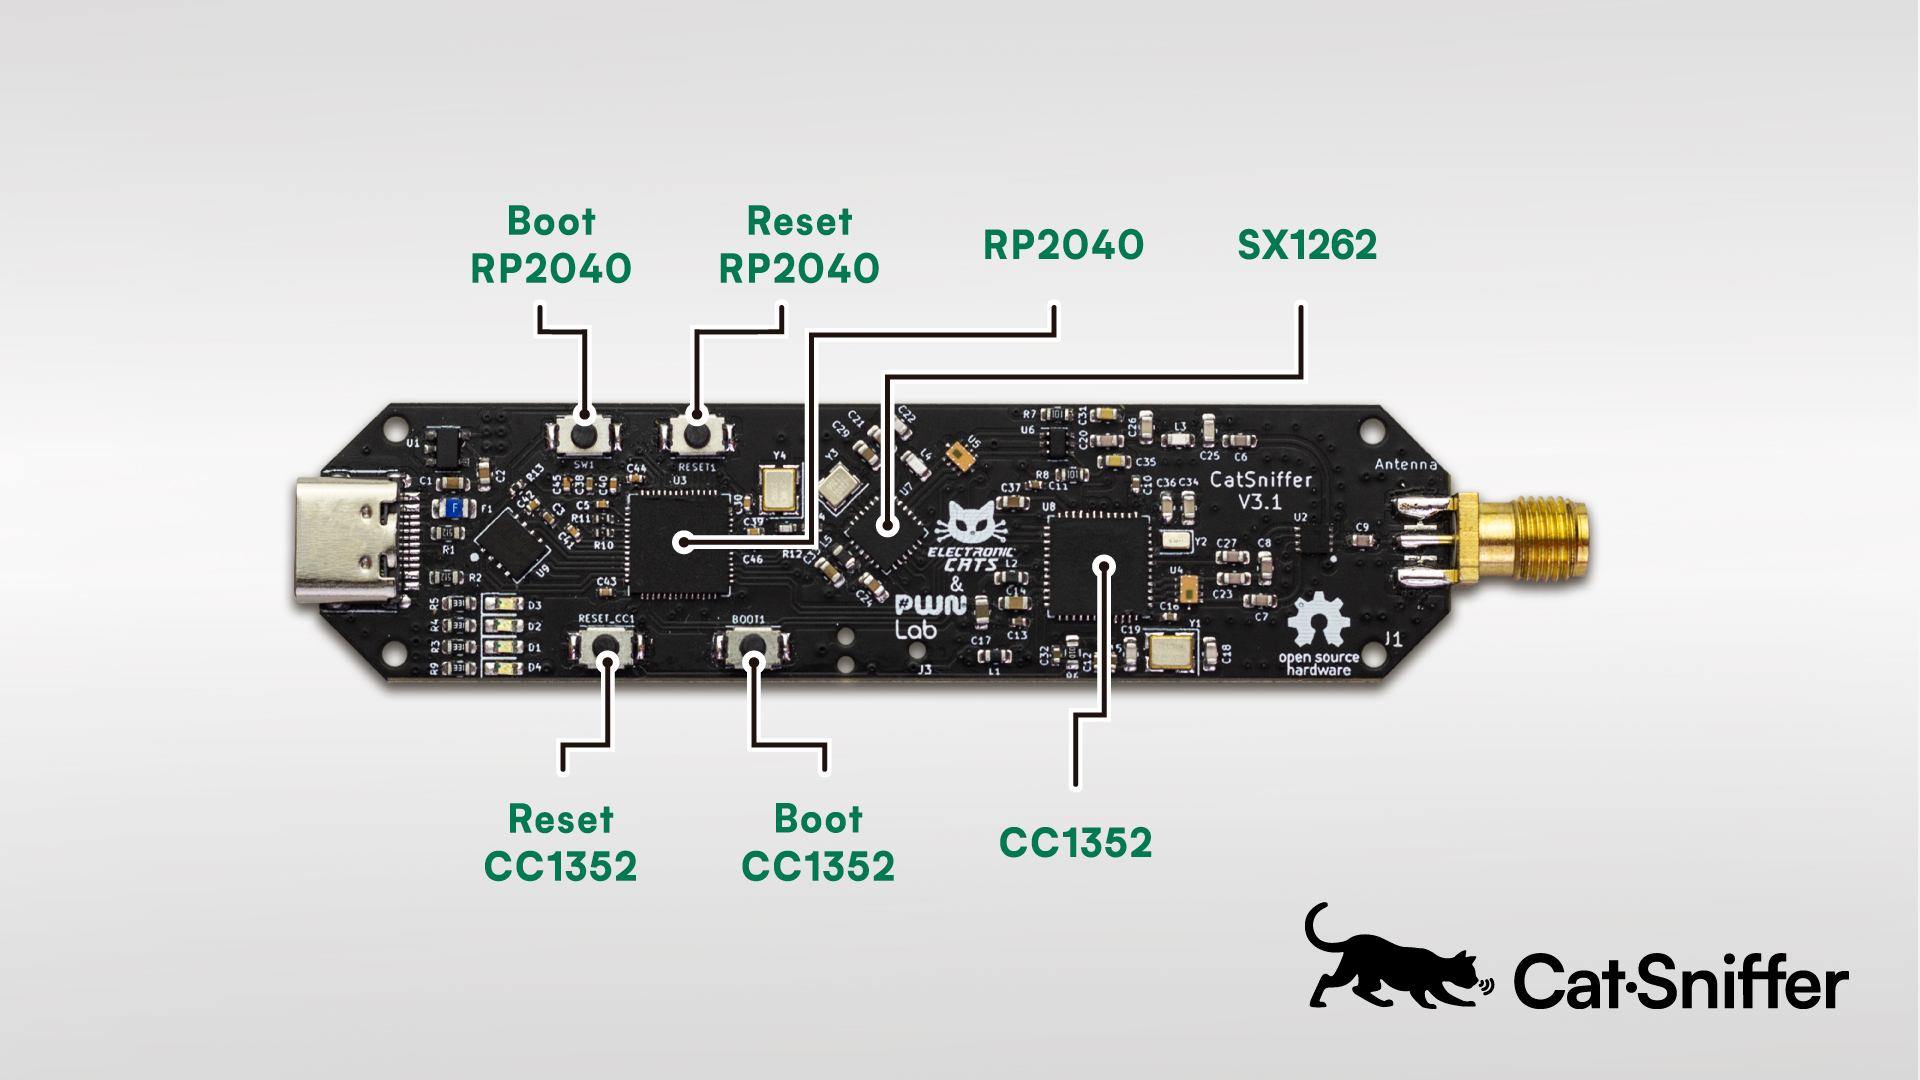

#### 4.1 Inspecting Output from the Serial Port

Once the CatSniffer firmware has been flashed successfully, the next step is to **inspect the device’s serial output**.  
This allows you to verify that the firmware is running correctly, monitor logs, and interact with the device if it expects serial commands.

By default, the **official CatSniffer firmwares** communicate at a baud rate of **921600**.  
Make sure to configure your serial connection accordingly; using the wrong baud rate will result in garbled or unreadable output.

In this section, we will:
- Open a serial connection to the CatSniffer.
- Confirm that the device responds with the expected startup messages.
- Observe real-time logs as the firmware operates.

This step is essential to validate that the CatSniffer is alive and ready before moving on to advanced tasks such as sniffing, fuzzing, or replaying traffic.


In [ ]:
# --- What this cell does ----------------------------------------------------
# Single-process serial monitor (no threads) for CatSniffer/Minino.
# Uses asyncio + pyserial (blocking reads with short timeout) and appends output
# to a widgets.Output via append_stdout() for reliable rendering in notebooks.
#
# - Uses `selected_port`
# - Adjustable baud (default 921600)
# - Start / Stop buttons
# - Buffered line handling to avoid chopped output
# ---------------------------------------------------------------------------

import os, time, asyncio
import serial
from IPython.display import display
import ipywidgets as widgets

# Selected port
selected_port = ports_dropdown.value

# UI
baud_input = widgets.IntText(value=921600, description="Baud:")
start_btn  = widgets.Button(description="▶ Start", button_style="success")
stop_btn   = widgets.Button(description="⏹ Stop",  button_style="warning", disabled=True)
out        = widgets.Output()

_run_task = None
_stop_event = None

def _human_or_hex(line_bytes: bytes, nonprint_thresh: float = 0.35) -> str:
    if not line_bytes:
        return ""
    nonprint = sum(1 for b in line_bytes if b < 9 or (13 < b < 32) or b == 127)
    if nonprint / len(line_bytes) > nonprint_thresh:
        return line_bytes.hex().upper()
    return line_bytes.decode(errors="replace").rstrip("\r\n")

async def _serial_reader(port: str, baud: int, stop_event: asyncio.Event, out_widget: widgets.Output):
    ser = None
    buf = bytearray()

    # Small helper to print reliably into Output widget
    def _print(msg: str):
        out_widget.append_stdout(msg + "\n")
        
    try:
        # Use a short timeout so our loop can yield to the event loop
        ser = serial.Serial(port, baud, timeout=0.2)
    except serial.SerialException as e:
        _print(f"❌ Could not open serial port {port}: {e}")
        return
    
    # Give the device a moment to emit initial lines
    await asyncio.sleep(1.0)
    _print(f"✅ Serial connection established on {port} @ {baud} baud.")
    _print("Streaming output...\n")

    try:
        while not stop_event.is_set():
            try:
                chunk = ser.read(1024)
                if chunk:
                    buf.extend(chunk)
                    if b"\n" in buf:
                        lines = buf.split(b"\n")
                        buf = bytearray(lines.pop())
                        for ln in lines:
                            text = _human_or_hex(ln)
                            if text:
                                _print(text)
                # Yield to keep UI responsive
                await asyncio.sleep(0.01)
            except serial.SerialException as e:
                _print(f"[serial warning] {e}")
                break
            except Exception as e:
                _print(f"[read warning] {e}")
                await asyncio.sleep(0.05)
    finally:
        # Flush any trailing partial line
        if buf:
            text = _human_or_hex(bytes(buf))
            if text:
                _print(text)
        try:
            if ser and ser.is_open:
                ser.close()
        except Exception:
            pass
        _print("\n⏹ Serial reader stopped. Port closed.")

def _on_start(_):
    """Start button callback: schedules the reader task on the current event loop."""
    global _run_task, _stop_event
    if _run_task is not None and not _run_task.done():
        return  # already running

    out.clear_output()
    baud = int(baud_input.value)
    out.append_stdout(f"Opening {selected_port} at {baud} baud...\n\n")

    # Create a fresh stop event and schedule the task
    loop = asyncio.get_running_loop()
    _stop_event = asyncio.Event()
    _run_task = loop.create_task(_serial_reader(selected_port, baud, _stop_event, out))

    start_btn.disabled = True
    stop_btn.disabled  = False

async def _stop_and_wait():
    """Signal the reader to stop and wait for it to finish."""
    global _run_task, _stop_event
    if _run_task is None:
        return
    if _stop_event is not None and not _stop_event.is_set():
        _stop_event.set()
    try:
        await asyncio.wait_for(_run_task, timeout=4.0)
    except asyncio.TimeoutError:
        pass
    _run_task = None



def _on_stop(_):
    """Stop button callback: schedule async stopper without threads."""
    asyncio.create_task(_stop_and_wait())
    start_btn.disabled = False
    stop_btn.disabled  = True

start_btn.on_click(_on_start)
stop_btn.on_click(_on_stop)

display(baud_input, start_btn, stop_btn, out)
